# Projet Télédétection Avancée Master 2
## Bretagne 2024-2025
### Antoine Leroux

## 1. Initialisation de l'arborescence de fichiers
### 1.1. Import des bibliothèques

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.base import clone

sys.path.append("/home/onyxia/work/")

from libsigma import classification as cla
from libsigma import read_and_write as rw
from libsigma import plots
import my_fonction as mf

### 1.2. Configuration et chemins

In [2]:
workdir = '/home/onyxia/work/'
data = '/home/onyxia/work/data/projet_eval'
sample = os.path.join(data, 'PI_strates_bretagne_32630.shp')

# Création des dossiers
results = os.path.join(workdir, "results")
figure = os.path.join(results, "figure")
img = os.path.join(workdir, "img")

dossiers_a_creer = [results, figure, img]
for dossier in dossiers_a_creer:
    os.makedirs(dossier, exist_ok=True)

# Paramètres des données
bands = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
dates = [
    "2025-03-31", "2025-04-10", "2025-05-15",
    "2025-06-17", "2025-07-12", "2025-08-10"
]

# Dictionnaire des chemins
paths = {
    b: os.path.join(data, f"bretagne_24-25_{b}.tif")
    for b in bands
}

## 2. Analyse des échantillons (polygones et pixels)
### 2.1. Nombre d'échantillons (polygones)

Graphique sauvegardé : /home/onyxia/work/results/figure/diag_baton_nb_poly_by_class.png


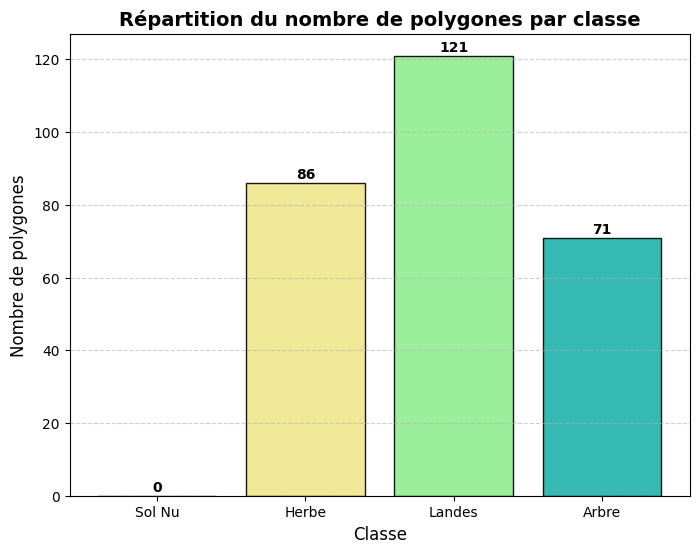

In [3]:
# Configuration
classes_attendues = [1, 2, 3, 4]
noms_classes = {1: "Sol Nu", 2: "Herbe", 3: "Landes", 4: "Arbre"}
strate_colors = {1: 'peru', 2: 'khaki', 3: 'lightgreen', 4: 'lightseagreen'}

labels = [noms_classes[c] for c in classes_attendues]
couleurs = [strate_colors[c] for c in classes_attendues]

# Chargement et comptage des polygones
gdf = gpd.read_file(sample)

raw_poly = gdf["strate"].value_counts().to_dict()

counts_poly = [raw_poly.get(c, 0) for c in classes_attendues]

# Configuration du graphique
plt.figure(figsize=(8, 6))
plt.bar(labels, counts_poly, color=couleurs, edgecolor='black', alpha=0.9)

plt.title("Répartition du nombre de polygones par classe", fontsize=14, fontweight='bold')
plt.ylabel("Nombre de polygones", fontsize=12)
plt.xlabel("Classe", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

offset = max(counts_poly) * 0.01 if max(counts_poly) > 0 else 0.1
for i, val in enumerate(counts_poly):
    txt_val = f"{val:,}".replace(',', ' ')
    plt.text(i, val + offset, txt_val, ha='center', fontweight='bold')

# Sauvegarde
filename = "diag_baton_nb_poly_by_class.png"
save_path = os.path.join(figure, filename)
plt.savefig(save_path, bbox_inches='tight')
print(f"Graphique sauvegardé : {save_path}")

plt.show()

#### Commentaire : 
Le diagramme révèle une prédominance marquée du nombre de polygones pour la classe « Landes », suivie des classes « Herbe » et « Arbre », tandis que la classe « Sol nu » est absente. Cette distribution n'est pas fortuite : elle reflète la stratégie d'échantillonnage ciblée de notre étude. L'objectif principal étant la détection et la cartographie précise des landes, un effort de saisie particulier a été réalisé sur cette classe pour capturer toute sa diversité spectrale et spatiale.


### 2.2. Nombre d'échantillons (pixels)

Graphique sauvegardé : /home/onyxia/work/results/figure/diag_baton_nb_pix_by_class.png


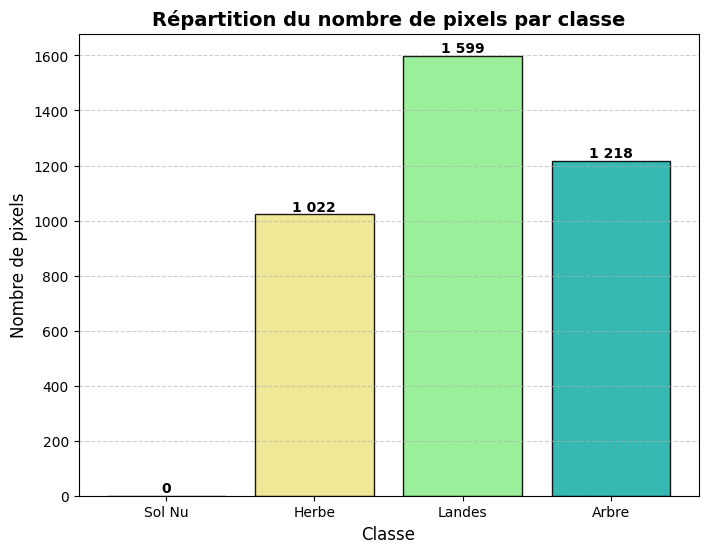

In [4]:
# Calcul du nombre de pixels (Rasterisation)
ref_image = paths['B02']

masque_array = mf.rasterization(sample, ref_image, "strate")

raw_pix_vals, raw_pix_counts = np.unique(masque_array, return_counts=True)
raw_pix_dict = dict(zip(raw_pix_vals, raw_pix_counts))

counts_pix = [int(raw_pix_dict.get(c, 0)) for c in classes_attendues]

# Configuration du graphique
plt.figure(figsize=(8, 6))
plt.bar(labels, counts_pix, color=couleurs, edgecolor='black', alpha=0.9)

plt.title("Répartition du nombre de pixels par classe", fontsize=14, fontweight='bold')
plt.ylabel("Nombre de pixels", fontsize=12)
plt.xlabel("Classe", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

offset = max(counts_poly) * 0.01 if max(counts_poly) > 0 else 0.1
for i, val in enumerate(counts_pix):
    txt_val = f"{val:,}".replace(',', ' ')
    plt.text(i, val, txt_val, ha='center', va='bottom', fontweight='bold')

# Sauvegarde
filename = "diag_baton_nb_pix_by_class.png"
save_path = os.path.join(figure, filename)
plt.savefig(save_path, bbox_inches='tight')
print(f"Graphique sauvegardé : {save_path}")

plt.show()

#### Commentaire :
L’analyse de la répartition des échantillons montre une dominance de la classe « Landes », suivie des classes « Arbre » et « Herbe », tant en nombre de polygones qu’en nombre de pixels, tandis que la classe « Sol nu » n’est pas représentée. Le diagramme du nombre de pixels indique une répartition satisfaisante des échantillons, avec plus de 1 000 pixels pour chaque classe présente. Cette distribution permet un apprentissage relativement équilibré et limite le risque de biais lié à la surreprésentation d’une classe lors de la classification supervisée.

### 2.3. Phénologie des strates, mise en évidence des landes

Calcul ARI -> ARI_serie_temp.tif


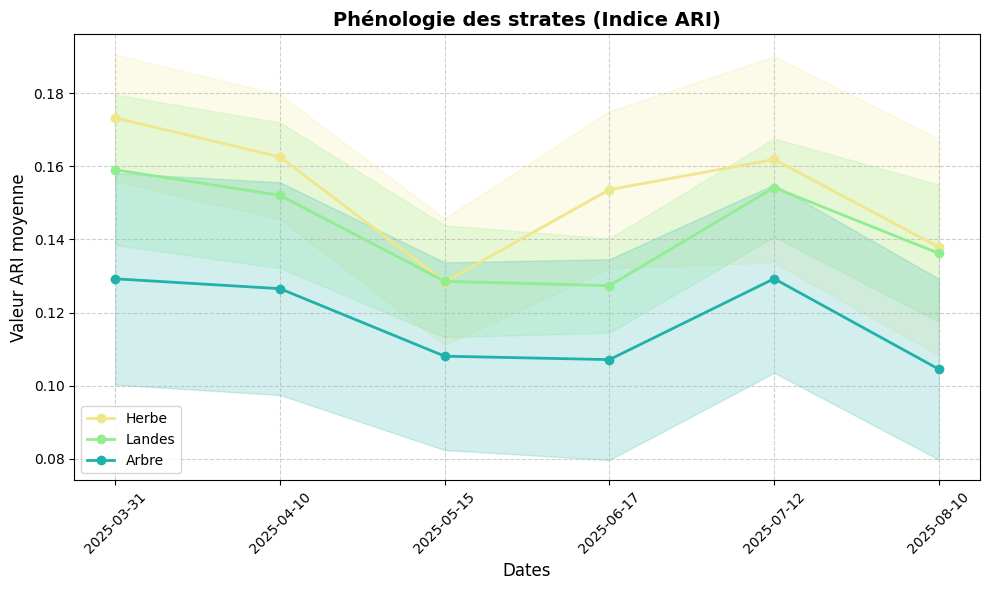

In [5]:
output_ari = os.path.join(results, "ARI_serie_temp.tif")
output_fig_ari = os.path.join(figure, "ARI_series.png")

# Calcul de l'ARI
mf.calculate_ari(
    path_b03=paths['B03'], 
    path_b05=paths['B05'], 
    output_path=output_ari, 
    dates=dates
)

# Configuration du profil phénologique
mf.plot_phenology(
    ari_path=output_ari, 
    mask_array=masque_array, 
    output_fig_path=output_fig_ari, 
    dates=dates
)

#### Commentaire :
L’analyse de l’évolution de l’indice ARI montre que la classe Landes se distingue des autres strates par une dynamique phénologique spécifique, avec des valeurs d’ARI généralement supérieures à celles de la classe Arbre et proches de celles de la classe Herbe. Toutefois, certaines périodes de l’année, notamment au printemps et en début d’été, présentent des valeurs d’ARI similaires entre les classes Landes et Herbe, suggérant des confusions potentielles entre ces strates à certaines dates. À l’inverse, la classe Arbre conserve des valeurs plus faibles et une variabilité plus limitée, ce qui la rend plus facilement différenciable. Ainsi, la distinction de la classe Landes repose à la fois sur son niveau d’ARI et sur sa trajectoire temporelle, même si des chevauchements ponctuels peuvent limiter la séparabilité à certaines dates.

## 3. Production d’une carte de strates à l’échelle du pixel
### 3.1. Choix du classifieur et sa paramètrisation

In [6]:
# Chemins des fichiers
stack_path = os.path.join(results, "stack_complet.tif")
roi_raster_class = os.path.join(results, "sample_rasterized_class.tif")
roi_raster_id = os.path.join(results, "sample_rasterized_id_unique.tif")
temp_shapefile = os.path.join(results, "temp_samples_with_uid.shp")

# Construction du Stack
mf.stack(paths, output_ari, dates, stack_path)

# Gestion des IDs uniques
gdf = gpd.read_file(sample)
gdf['uid'] = gdf.index + 1
gdf.to_file(temp_shapefile)

# Rasterisation
ds_ref = rw.open_image(stack_path)

mask_class = mf.rasterization(sample, stack_path, "strate")
rw.write_image(roi_raster_class, mask_class, data_set=ds_ref, nb_band=1)

mask_id = mf.rasterization(temp_shapefile, stack_path, "uid")
rw.write_image(roi_raster_id, mask_id, data_set=ds_ref, nb_band=1)

# Extraction finale
X, y, _ = cla.get_samples_from_roi(stack_path, roi_raster_class)
_, groups, _ = cla.get_samples_from_roi(stack_path, roi_raster_id)

y = np.asarray(y).ravel()
groups = np.asarray(groups).ravel()

### 3.2. Stratégie de validation

In [7]:
# Séparation Train / Test
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=1)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

# Optimisation GridSearch
rf = RandomForestClassifier(random_state=1, n_jobs=-1)

param_grid = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [None, 10, 15, 20],
    'max_features': [None, 'sqrt', 'log2'],
    'min_samples_leaf': [1, 5]
}

# Validation Croisée Groupée
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train, groups=groups_train)
best_model = grid_search.best_estimator_

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score validataion croisée : {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 120 candidates, totalling 360 fits


Meilleurs paramètres : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Meilleur score validataion croisée : 0.8996


#### Commentaire :
La recherche des hyperparamètres par validation croisée stratifiée et groupée a conduit à un modèle de forêt aléatoire composé de 300 arbres, sans contrainte de profondeur et utilisant une sélection aléatoire des variables à chaque division. Le score moyen de validation croisée atteint 0,89, indiquant une bonne capacité de généralisation du modèle. L’utilisation d’une validation croisée groupée renforce la robustesse de ce résultat en limitant les biais liés à l’autocorrélation des données, ce qui suggère que les variables spectrales et phénologiques mobilisées sont pertinentes pour la discrimination des classes, notamment celle des landes. L’ensemble des variables disponibles a ainsi été conservé pour la classification afin de prendre en compte l’intégralité de l’information spectrale et phénologique. Les analyses préalables ont montré que certaines classes présentent des valeurs proches à certaines dates, rendant une discrimination mono-temporelle insuffisante. L’utilisation de l’ensemble des variables permet de capturer la dynamique temporelle complète des strates. Par ailleurs, le recours à un classifieur de type Random Forest, peu sensible à la redondance des variables, ainsi que les bons résultats obtenus en validation croisée, confirment la pertinence de cette approche.

### 3.3. Contribution des variables

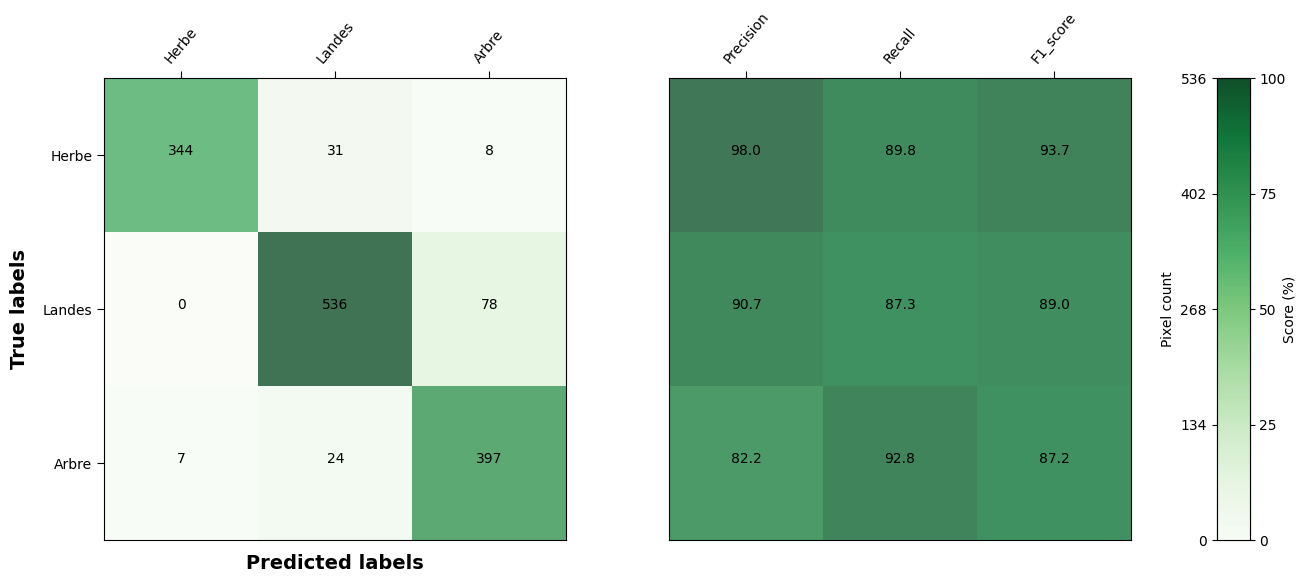

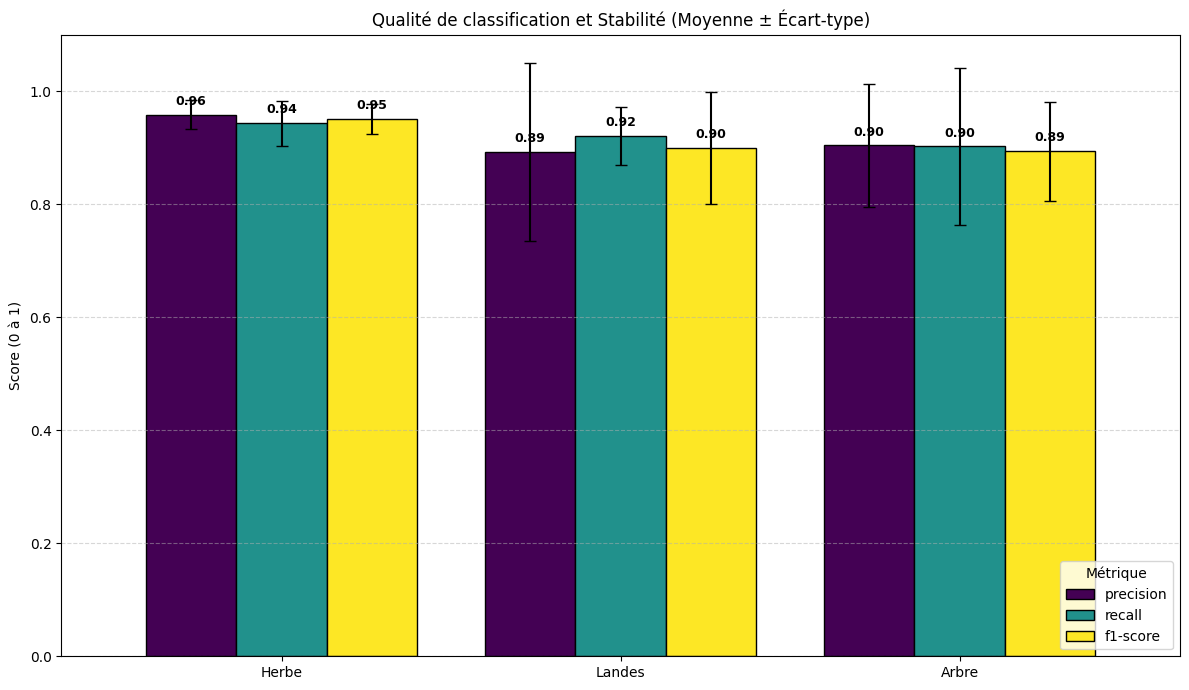

In [8]:
# Matrice de confusion
y_pred_test = best_model.predict(X_test)

classes_presentes = np.unique(np.concatenate((y_test, y_pred_test)))
labels_noms = [noms_classes[c] for c in classes_presentes]

cm = confusion_matrix(y_test, y_pred_test, labels=classes_presentes)

plots.plot_cm(
    cm, 
    labels=labels_noms, 
    normalize=False,
    out_filename=os.path.join(figure, "matrice_confusion.png")
)
plt.show()

# Graphique de Stabilité
cv_stats = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)
list_reports = []

for train_ix, val_ix in cv_stats.split(X_train, y_train, groups=groups_train):
    
    X_t_fold, X_v_fold = X_train[train_ix], X_train[val_ix]
    y_t_fold, y_v_fold = y_train[train_ix], y_train[val_ix]
    
    clf = clone(best_model)
    clf.fit(X_t_fold, y_t_fold)
    
    pred_v = clf.predict(X_v_fold)
    
    rep = classification_report(y_v_fold, pred_v, output_dict=True, zero_division=0)
    list_reports.append(pd.DataFrame(rep).transpose())

# Agrégation des résultats
all_results = pd.concat(list_reports)
mean_df = all_results.groupby(all_results.index).mean()
std_df = all_results.groupby(all_results.index).std()

classes_str = [str(k) for k in noms_classes.keys() if str(k) in mean_df.index]
labels_reels = [noms_classes[int(k)] for k in classes_str]

metrics = ['precision', 'recall', 'f1-score']
df_plot_mean = mean_df.loc[classes_str, metrics]
df_plot_std = std_df.loc[classes_str, metrics]

df_plot_mean.index = labels_reels
df_plot_std.index = labels_reels

ax = df_plot_mean.plot(
    kind='bar', 
    yerr=df_plot_std,
    figsize=(12, 7),
    rot=0,
    capsize=4,
    colormap='viridis',
    edgecolor='black',
    width=0.8
)

plt.title("Qualité de classification et Stabilité (Moyenne ± Écart-type)")
plt.ylabel("Score (0 à 1)")
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right', title="Métrique")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

#### Commentaire matrice de confusion :
La matrice de confusion montre une bonne performance globale du modèle, avec une majorité des pixels correctement classés sur la diagonale pour les trois classes. La classe Herbe est bien discriminée, avec peu de confusions, principalement avec la classe Landes. La classe Landes présente également un bon taux de classification correcte, mais montre des confusions notables avec la classe Arbre, ce qui confirme les proximités spectrales et phénologiques observées lors de l’analyse de l’indice ARI. La classe Arbre est globalement bien reconnue, avec quelques confusions vers la classe Landes.

Les métriques associées confirment ces observations. La classe Herbe présente une précision élevée (98,0 %), indiquant peu de faux positifs, mais un rappel légèrement plus faible (89,8 %), traduisant quelques omissions. La classe Landes affiche des performances équilibrées, avec une précision de 90,7 % et un rappel de 87,3 %, soulignant une bonne mais imparfaite séparabilité, notamment vis-à-vis des formations arborées. La classe Arbre se distingue par un rappel élevé (92,8 %), mais une précision plus faible (82,2 %), indiquant une tendance à être confondue avec la classe Landes. Les scores F1, compris entre 87,2 % et 93,7 %, traduisent une performance globale satisfaisante et cohérente avec les résultats de la validation croisée.

#### Commentaire qualité de classification :
Cette figure présente les performances moyennes de classification (précision, rappel et F1-score), ainsi que leur variabilité, pour les classes Herbe, Landes et Arbre. Globalement, les scores moyens sont élevés pour l’ensemble des classes, confirmant la bonne qualité du modèle de classification.

La classe Herbe présente les meilleures performances globales, avec des scores proches de 0,95 et une faible variabilité, traduisant une classification à la fois précise et stable. La classe Landes affiche des performances légèrement inférieures, en particulier pour la précision, et une variabilité plus marquée, ce qui indique une classification plus sensible aux variations des échantillons et confirme les confusions observées précédemment, notamment avec la classe Arbre. La classe Arbre présente des scores intermédiaires et une variabilité notable, traduisant une bonne capacité de détection mais une stabilité légèrement moindre, en cohérence avec les confusions mises en évidence dans la matrice de confusion.

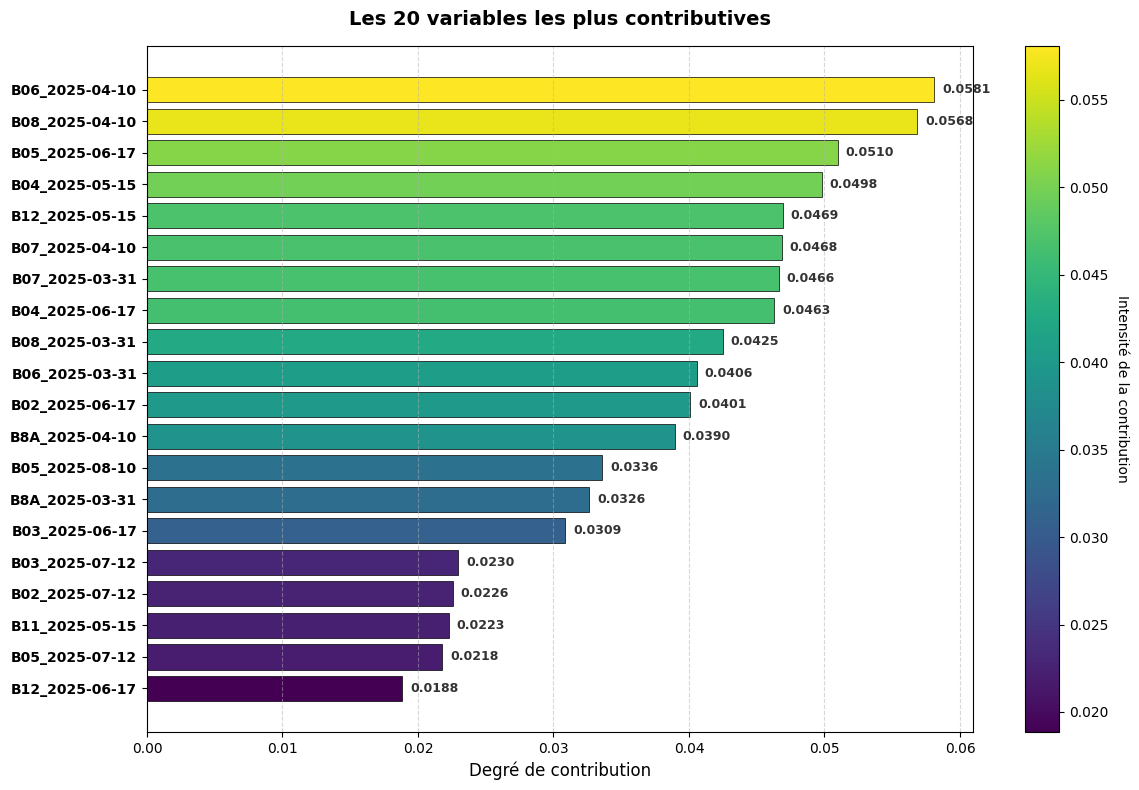

In [9]:
# Contribution des variables
noms_variables = []
for bande in paths.keys():
    for date in dates:
        noms_variables.append(f"{bande}_{date}")

for date in dates:
    noms_variables.append(f"ARI_{date}")

feature_names = np.array(noms_variables)
nb_vars_modele = best_model.feature_importances_.shape[0]

if len(feature_names) != nb_vars_modele:
    feature_names = np.array([f"Var_{i}" for i in range(nb_vars_modele)])

# Sélection des variables
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 20
top_indices = indices[:top_n]
top_importances = importances[top_indices]
top_names = feature_names[top_indices]

# Préparation du graphique
plt.figure(figsize=(12, 8))
colormap = plt.cm.viridis
norm = mcolors.Normalize(vmin=top_importances.min(), vmax=top_importances.max())
bar_colors = colormap(norm(top_importances))

plt.barh(range(top_n), top_importances, color=bar_colors, edgecolor='black', linewidth=0.5)
plt.gca().invert_yaxis()
plt.yticks(range(top_n), top_names, fontsize=10, fontweight='bold')
plt.xlabel("Degré de contribution", fontsize=12)
plt.title(f"Les {top_n} variables les plus contributives", fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)

max_val = max(top_importances)
for i, v in enumerate(top_importances):
    plt.text(v + (max_val * 0.01), i, f"{v:.4f}", 
             va='center', fontsize=9, fontweight='bold', color='#333333')

sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca()) 
cbar.set_label('Intensité de la contribution', rotation=270, labelpad=15)

# Sauvegarde et affichage
plt.tight_layout()
path_fig = os.path.join(figure, "importance_variables.png")
plt.savefig(path_fig, dpi=150, bbox_inches='tight')
plt.show()

#### Commentaires :
Les variables les plus contributives au modèle correspondent principalement à des bandes Sentinel-2 liées à la végétation, notamment la bande B04 (rouge), sensible à l’absorption chlorophyllienne, les bandes du red edge B05, B06 et B07, particulièrement adaptées à la discrimination des types de végétation et à l’analyse de leur vigueur, ainsi que les bandes du proche infrarouge B08 et B8A, fortement corrélées à la biomasse et à la structure du couvert végétal. Les bandes SWIR B11 et B12, sensibles à la teneur en eau et à la structure des formations végétales, apparaissent également contributives. La présence récurrente de ces bandes à plusieurs dates, principalement au printemps et au début de l’été, confirme que la classification repose sur la dynamique phénologique des couverts, en cohérence avec les analyses de l’indice ARI et les performances obtenues par le modèle.

### 3.4. Production des cartes finales

In [10]:
# Définition des chemins
output_map = os.path.join(results, "carte_strates.tif")

arr_img = rw.load_img_as_array(stack_path, verbose=False)
h, w, nb_band = arr_img.shape

X_full = arr_img.reshape(-1, nb_band)

y_map_flat = best_model.predict(X_full)

y_map = y_map_flat.reshape(h, w)

# Sauvegarde du fichier
ds_ref = rw.open_image(stack_path)
rw.write_image(output_map, y_map, data_set=ds_ref, nb_band=1)

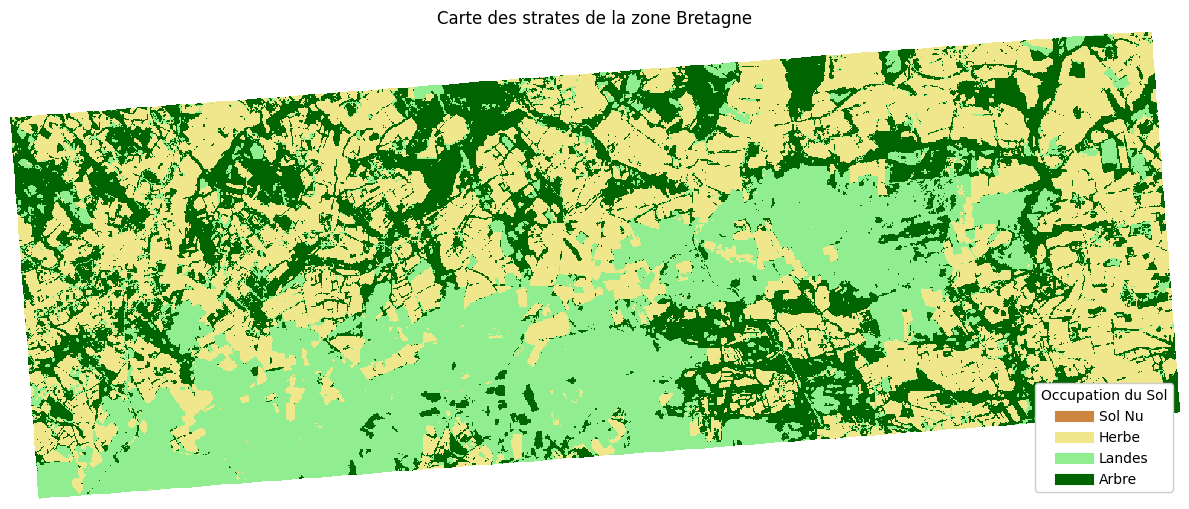

In [11]:
# Chargement des données
arr3d = rw.load_img_as_array(output_map, verbose=False)
carte = arr3d[:, :, 0]
ref_data = rw.load_img_as_array(stack_path, verbose=False)

# Masquage du fond (No Data)
mask_nan = np.any(np.isnan(ref_data), axis=2)
mask_zero = np.max(ref_data, axis=2) == 0
carte[mask_nan | mask_zero] = 0

# Configuration visuelle
color_list = ['white', 'peru', 'khaki', 'lightgreen', 'darkgreen']
cmap = mcolors.ListedColormap(color_list)
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Affichage de la carte
plt.figure(figsize=(12, 12))
plt.imshow(carte, cmap=cmap, norm=norm, interpolation='nearest')

for val, label in noms_classes.items():
    plt.plot([], [], color=color_list[val], label=label, linewidth=8)

plt.legend(title="Occupation du Sol", loc="lower right", framealpha=1, facecolor='white')
plt.title("Carte des strates de la zone Bretagne")
plt.axis("off") 
plt.tight_layout()
plt.show()

#### Commentaires :
La carte de classification met en évidence une distribution spatiale cohérente des strates végétales, avec des formations arborées bien structurées et des classes herbacées et de landes plus fragmentées. La classe « Landes » occupe une position intermédiaire, souvent en transition entre les autres strates, reflétant sa dynamique écologique. La classe « Sol nu » est absente de la carte, ce qui confirme la forte couverture végétale de la zone d’étude.

### 3.5. Analyse des résultats

L’analyse conjointe de la carte produite et des matrices de confusion met en évidence une bonne qualité globale du modèle de classification. Les performances élevées obtenues en validation croisée et sur le jeu de test, avec des scores F1 supérieurs à 87 % pour l’ensemble des classes, traduisent une capacité satisfaisante du modèle à généraliser. La cohérence spatiale observée sur la carte de classification finale confirme ces résultats, avec une structuration réaliste des strates végétales et une absence d’artefacts majeurs.

La qualité de classification varie toutefois selon les classes. La classe Herbe est la mieux classée, avec une précision et un score F1 élevés, traduisant une bonne séparabilité spectrale et phénologique. La classe Arbre présente également de bonnes performances, notamment en rappel, indiquant une bonne capacité de détection des formations arborées, bien que des confusions subsistent. La classe Landes, bien que globalement bien discriminée, apparaît comme la plus délicate à classer, avec des performances légèrement inférieures et une variabilité plus importante, reflétant sa forte hétérogénéité spatiale et spectrale.

Les confusions observées concernent principalement les classes Herbe et Landes, ainsi que Landes et Arbre. Ces confusions sont cohérentes d’un point de vue écologique et phénologique, les landes occupant une position intermédiaire entre formations herbacées et arborées. Les analyses de l’indice ARI ont montré que certaines de ces classes présentent des valeurs proches à certaines dates, ce qui explique les confusions ponctuelles observées, notamment dans les zones de transition spatiale visibles sur la carte. L’absence de la classe Sol nu est cohérente avec le contexte paysager de la zone d’étude et n’a pas affecté la qualité globale de la classification.

Enfin, l’analyse spatiale permet d’identifier des zones particulièrement bien classées, correspondant à des surfaces homogènes (massifs boisés, prairies continues), et des zones plus incertaines situées aux interfaces entre classes, confirmant que les erreurs de classification sont principalement localisées dans des contextes de transition écologique plutôt que réparties aléatoirement.

### Diagramme de flux

![diag](img/diagramme_de_flux.png)